In [1]:
import numpy as np
import sympy as smp
import matplotlib.pyplot as plt

# Textbook Example

$$\begin{align}\dot x =& \sigma(y-x)\\
\dot y =& \rho x + x - y - xz \\
\dot z =& -\beta z + xy\end{align}$$

In [2]:
x, y, z, sig, rho, bet = smp.symbols(r'x y z \sigma \rho \beta')

dx = sig*(y-x)
dx

\sigma*(-x + y)

In [3]:
dy = rho*x+x-y-x*z
dy

\rho*x - x*z + x - y

In [4]:
dz = -bet*z + x*y
dz

-\beta*z + x*y

In [5]:
Jac = smp.Matrix([[smp.diff(dx,x),smp.diff(dx,y),smp.diff(dx,z)],
                  [smp.diff(dy,x),smp.diff(dy,y),smp.diff(dy,z)],
                  [smp.diff(dz,x),smp.diff(dz,y),smp.diff(dz,z)]])
Jac.subs([[x,0],[y,0],[z,0],[rho,0]])

Matrix([
[-\sigma, \sigma,      0],
[      1,     -1,      0],
[      0,      0, -\beta]])

In [6]:
e1 = (smp.Matrix.eigenvects(Jac.subs([[x,0],[y,0],[z,0],[rho,0]])))[0][0]
v1 = (smp.Matrix.eigenvects(Jac.subs([[x,0],[y,0],[z,0],[rho,0]])))[0][-1][0]

e2 = (smp.Matrix.eigenvects(Jac.subs([[x,0],[y,0],[z,0],[rho,0]])))[1][0]
v2 = (smp.Matrix.eigenvects(Jac.subs([[x,0],[y,0],[z,0],[rho,0]])))[1][-1][0]

e3 = (smp.Matrix.eigenvects(Jac.subs([[x,0],[y,0],[z,0],[rho,0]])))[2][0]
v3 = (smp.Matrix.eigenvects(Jac.subs([[x,0],[y,0],[z,0],[rho,0]])))[2][-1][0]

### Change of Base

In [7]:
T = smp.Matrix([[v1.T],[-v3.T],[v2.T]]).T
T

Matrix([
[1, \sigma, 0],
[1,     -1, 0],
[0,      0, 1]])

In [8]:
u, v, w = smp.symbols(r'u v w')

uvw = smp.Matrix([[u],[v],[w]])
xyz = smp.Matrix([[x],[y],[z]])

In [9]:
xyz_change = T@uvw
xyz_change

Matrix([
[\sigma*v + u],
[       u - v],
[           w]])

In [10]:
T_inv = T.inv()
# T_inv = smp.Matrix([[1,sig,0],[1,-1,0],[0,0,1+sig]])
T_inv

Matrix([
[1/(\sigma + 1), \sigma/(\sigma + 1), 0],
[1/(\sigma + 1),     -1/(\sigma + 1), 0],
[             0,                   0, 1]])

In [11]:
uvw_dot = T_inv@xyz
uvw_dot = uvw_dot.subs([[x,dx],
                        [y,dy],
                        [z,dz]])
uvw_dot

Matrix([
[\sigma*(\rho*x - x*(-\beta*z + x*y) - y)/(\sigma + 1) + \sigma*(\rho*x - x*(-\beta*z + x*y) + x - y)/(\sigma + 1)],
[       \sigma*(\rho*x - x*(-\beta*z + x*y) - y)/(\sigma + 1) - (\rho*x - x*(-\beta*z + x*y) + x - y)/(\sigma + 1)],
[                                                                                                   -\beta*z + x*y]])

In [12]:
uvw_dot[0]

\sigma*(\rho*x - x*(-\beta*z + x*y) - y)/(\sigma + 1) + \sigma*(\rho*x - x*(-\beta*z + x*y) + x - y)/(\sigma + 1)

In [13]:
u_dot, v_dot, w_dot = uvw_dot.subs([[x,xyz_change[0]],
                                    [y,xyz_change[1]],
                                    [z,xyz_change[2]]])

In [14]:
u_dot.expand()

2*\beta*\sigma**2*v*w/(\sigma + 1) + 2*\beta*\sigma*u*w/(\sigma + 1) + 2*\rho*\sigma**2*v/(\sigma + 1) + 2*\rho*\sigma*u/(\sigma + 1) - 2*\sigma**3*u*v**2/(\sigma + 1) + 2*\sigma**3*v**3/(\sigma + 1) - 4*\sigma**2*u**2*v/(\sigma + 1) + 4*\sigma**2*u*v**2/(\sigma + 1) + \sigma**2*v/(\sigma + 1) - 2*\sigma*u**3/(\sigma + 1) + 2*\sigma*u**2*v/(\sigma + 1) - \sigma*u/(\sigma + 1) + 2*\sigma*v/(\sigma + 1)

In [15]:
v_dot.expand().simplify()

(\beta*\sigma**2*v*w + \beta*\sigma*u*w - \beta*\sigma*v*w - \beta*u*w + \rho*\sigma**2*v + \rho*\sigma*u - \rho*\sigma*v - \rho*u - \sigma**3*u*v**2 + \sigma**3*v**3 - 2*\sigma**2*u**2*v + 3*\sigma**2*u*v**2 - \sigma**2*v**3 - \sigma*u**3 + 3*\sigma*u**2*v - 2*\sigma*u*v**2 - \sigma*u + u**3 - u**2*v - v)/(\sigma + 1)

In [16]:
w_dot.expand()

-\beta*w + \sigma*u*v - \sigma*v**2 + u**2 - u*v

# Problem 1

For each of the following systems, do a center manifold reduction at the origin (with the bifuraction occurring at $\epsilon=0$ and use the equation for the center manifold dynamics to classify the bifurcation type.

## A 

suppose $x$ is on $S$ (the circle, 0 to $2\pi$) and $v\in\mathbb{R}$.
$$\begin{align}\frac{dx}{dt} =&\; -x + \epsilon v + v^2\\
\frac{dv}{dt} =&\; - \sin x\end{align}$$

---

Since $\dot x$ is the function that is dependent on the bifurcation parameter, $\epsilon$, $x$ will be the variable to build the equation $h(x,\epsilon)$.

$$\begin{align}\dot x =& -x + (\epsilon v + v^2) \\
\dot v =&  (-\sin x) \end{align}\begin{cases}A = -1\\
g_1 = \epsilon v + v^2\\
B = 0\\
g_2 = -\sin x\end{cases}$$

Which all is plugged into the equation

$$\mathcal{N} = 0 = Dh(Ay + g_1) -Bh - g_2$$

Now $h(x,\epsilon)$ needs to be designed. It is helpfult to select $h(x,\epsilon)$ so it simplifies the coefficient matching when solving $\mathcal{N}$. Observe the terms in $g_1$ with powers of $\epsilon$, so $h(x,\epsilon)$ shold have a term $a\epsilon$. To account for the terms in $g_2$ the taylor expansion is used

$$sin(x) \approx -x + \frac{x^3}{3!} - \frac{x^5}{5!} + \frac{x^7}{7!}$$

For a first itteration, only the first two terms will be considered. The resulting $h(x,\epsilon)$ is

$$h = a \epsilon + b x + c x^3$$

where $a,b,c$ are the parameters solved for to make $\mathcal{N}=0$. Which is done with the following symbolic solver

### Define symbolic variables

In [94]:
x, v, eps = smp.symbols(r'x v \epsilon')

dx = -x + eps*v + v**2
dx

\epsilon*v + v**2 - x

In [95]:
dv = -smp.sin(x)
dv

-sin(x)

### Center manifold

In [96]:
taylor_sin = x - x**3/(3*2) #+ x**5/(5*4*3*2) - x**7/(7*6*5*4*3*2)
taylor_sin

-x**3/6 + x

In [97]:
h, a, b, c, d = smp.symbols(r'h a b c d')

In [98]:
h = a*x + b*x**2 + c*x*eps

A = -1
B = 0
g1 = (eps*v + v**2).subs(v,h)
g2 = -taylor_sin # smp.sin(x)

dh = smp.diff(h,x)

N = (dh*(A*x + g1)-B*h - g2)
N

-x**3/6 + x + (\epsilon*c + a + 2*b*x)*(\epsilon*(\epsilon*c*x + a*x + b*x**2) - x + (\epsilon*c*x + a*x + b*x**2)**2)

`.expand()` just *expands* all the multiplication. It is a necessary step, so that **sympy** can collect terms.

In [99]:
N = N.expand()

`.coeff(x,0)` collects all the *coefficients* in `N` with a `x` power of `0`. Then `.coeff(eps,1)` collects coefficients of that set.

In [100]:
x_eps = N.coeff(x,1).coeff(eps,1)
x_eps

a**2 - c

In [101]:
x_pow1 = N.coeff(x,1).coeff(eps,0)
x_pow1

1 - a

In [102]:
x_pow2 = N.coeff(x,2).coeff(eps,0)
x_pow2

a**3 - 2*b

In [103]:
x_pow3 = N.coeff(x,3).coeff(eps,0)
x_pow3

4*a**2*b - 1/6

In [104]:
N.coeff(x,0).coeff(eps,2)

0

That should fill out all the terms for $h$. `.solve()` finds the solutions for the three above equations.

In [105]:
abc = smp.solve([x_pow1,x_pow3,x_eps],[a,b,c,])[0]
abc

(1, 1/24, 1)

`.subs()` *substitutes* symbolic variables of an existing equation; below I am filling in `h` with the above solutions `abc`.

In [106]:
h_sub = h.subs([[a,abc[0]],[b,abc[1]],[c,abc[2]]])
h_sub

\epsilon*x + x**2/24 + x

Similarly, `v` is subbstituted for `h_sub` in `dx` (again `dx` $=\dot x$)

In [107]:
dx_sub = dx.subs(v,h_sub)
dx_sub

\epsilon*(\epsilon*x + x**2/24 + x) - x + (\epsilon*x + x**2/24 + x)**2

`.lambdify()` converts a symbolic variable into a numerical function.

In [108]:
dx_func = smp.lambdify([eps,x],dx_sub)
dv_func = smp.lambdify([eps,x],dv)
h_func = smp.lambdify([eps,x],h_sub)

In [109]:
def de(e,x):
    return 0 

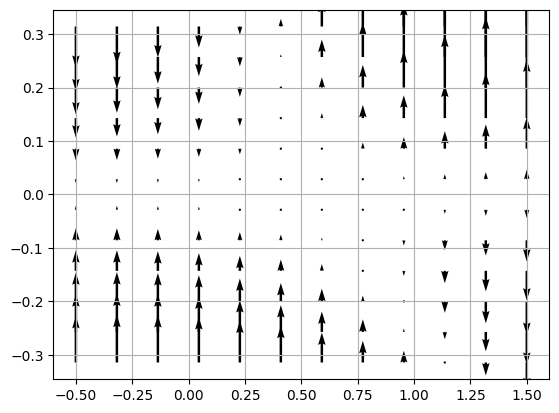

In [114]:
xv = np.linspace(-np.pi,np.pi,12)/10
ev = np.linspace(-5,15,12)/10

eG, xG = np.meshgrid(ev,xv)


plt.quiver(eG,xG,de(eG,xG),dx_func(eG,xG))

plt.grid()

plt.show()

## B 

suppose $x,y\in\mathbb{R}$, and
$$\begin{align}\frac{dx}{dt} =&\; \frac{x}{2} + y + x^2y\\
\frac{dy}{dt} =&\; x + 2y + \epsilon y + y^2\end{align}$$

---

### Define system

In [34]:
x, y, eps, A, B, g1, g2, u, v = smp.symbols(r'x y \epsilon A B g_1 g_2 u v')

dx = x/2 + y + x**2*y
dx

x**2*y + x/2 + y

In [35]:
dy = x + 2*y + eps*y + y**2
dy

\epsilon*y + x + y**2 + 2*y

### Jacobian

The 

In [36]:
Jac = smp.Matrix([[smp.diff(dx,x),smp.diff(dx,y)],
                  [smp.diff(dy,x),smp.diff(dy,y)]])

Jac

Matrix([
[2*x*y + 1/2,           x**2 + 1],
[          1, \epsilon + 2*y + 2]])

In [37]:
J0 = Jac.subs([[x,0],[y,0]])
J0.subs(eps,0)

Matrix([
[1/2, 1],
[  1, 2]])

In [38]:
J0 = J0.subs(eps,0)
smp.Matrix.eigenvals(J0)

{5/2: 1, 0: 1}

In [39]:
J0 = J0.subs(eps,0)
v1 = smp.Matrix.eigenvects(J0)[0][2][0]
v1

Matrix([
[-2],
[ 1]])

In [40]:
v2 = smp.Matrix.eigenvects(J0)[1][2][0]
v2

Matrix([
[1/2],
[  1]])

### $\mathcal{N}$

Since $\dot y$ is the function that is dependent on the bifurcation parameter, $\epsilon$, $y$ will be the variable to build the equation $h(y,\epsilon)$.

$$\begin{align}\dot y =& 2y + (\epsilon y + x + y^2) \\
\dot x =& \frac{1}{2}x + (x^2y + y) \end{align}\begin{cases}A = 2\\
g_1 = \epsilon y + x + y^2\\
B = \frac{1}{2}\\
g_2 = (x^2y + y)\end{cases}$$

Which all is plugged into the equation

$$\mathcal{N} = 0 = Dh(Ay + g_1) -Bh - g_2$$

Now $h(y,\epsilon)$ needs to be designed. It is helpfult to select $h(y,\epsilon)$ so it simplifies the coefficient matching when solving $\mathcal{N}$. Observe the terms in $g_1$ and $g_2$ with powers of $y$ and $\epsilon$: $y\epsilon$, $y^2$, and $y$. So $h(y,\epsilon)$ is selected as

$$h = a y + b y^2 + c y\epsilon$$

where $a,b,c$ are the parameters solved for to make $\mathcal{N}=0$. Which is done with the following symbolic solver

In [41]:
A = 2
B = 1/2

g1 = (dy - A*y)
g2 = (dx - B*x)

In [42]:
h = a*y + b*y**2 + c*eps*y
dh = smp.diff(h,y)
N = (dh*(A*x + g1)-B*h - g2).subs(x,h)
N

-0.5*\epsilon*c*y - 0.5*a*y - 0.5*b*y**2 - y*(\epsilon*c*y + a*y + b*y**2)**2 - y + (\epsilon*c + a + 2*b*y)*(3*\epsilon*c*y + \epsilon*y + 3*a*y + 3*b*y**2 + y**2)

`.expand()` just *expands* all the multiplication. It is a necessary step, so that **sympy** can collect terms.

In [43]:
N = N.expand()

`.coeff(eps,0)` collects all the *coefficients* in `N` with a `eps` power of `0`. Then `.coeff(y,1)` collects coefficients of that set.

In [44]:
y_pow1 = N.coeff(eps,0).coeff(y,1)
y_pow1

3*a**2 - 0.5*a - 1

In [45]:
y_pow2 = N.coeff(eps,0).coeff(y,2)
y_pow2

9*a*b + a - 0.5*b

In [46]:
y_eps = N.coeff(eps,1).coeff(y,1)
y_eps 

6*a*c + a - 0.5*c

That should fill out all the terms for $h$. `.solve()` finds the solutions for the three above equations.

In [47]:
abc = smp.solve([y_pow1,y_pow2,y_eps],[a,b,c])
abc

[(-0.500000000000000, -0.100000000000000, -0.142857142857143),
 (0.666666666666667, -0.121212121212121, -0.190476190476190)]

Two sets of $a,b,c$ were found. I wonder if one can be selected by looking at more terms of $\mathcal{N}$, but I am interested to see the difference in results. From my understanding of class discussions, it shouldn't matter which is selected.

`.subs()` *substitutes* symbolic variables of an existing equation; below I am filling in `h` with the above solutions `abc`.

In [48]:
h_sub1 = h.subs([[a,abc[0][0]],[b,abc[0][1]],[c,abc[0][2]]])
h_sub1

-0.142857142857143*\epsilon*y - 0.1*y**2 - 0.5*y

In [49]:
h_sub2 = h.subs([[a,abc[1][0]],[b,abc[1][1]],[c,abc[1][2]]])
h_sub2

-0.19047619047619*\epsilon*y - 0.121212121212121*y**2 + 0.666666666666667*y

Similarly, `x` is subbstituted for `h_sub` in `dy` (again `dy` $=\dot y$)

In [50]:
dy_sub1 =  dy.subs(x,h_sub1)
dy_sub1

0.857142857142857*\epsilon*y + 0.9*y**2 + 1.5*y

In [51]:
dy_sub2 =  dy.subs(x,h_sub2)
dy_sub2

0.80952380952381*\epsilon*y + 0.878787878787879*y**2 + 2.66666666666667*y

### Sim

`.lambdify()` converts a symbolic variable into a numerical function.

In [52]:
dx_subs = dx.subs(x,h_sub1)
dx_subs

-0.0714285714285714*\epsilon*y - 0.05*y**2 + y*(-0.142857142857143*\epsilon*y - 0.1*y**2 - 0.5*y)**2 + 0.75*y

In [53]:
dx

x**2*y + x/2 + y

In [54]:
dx_og = smp.lambdify([eps,x,y],dx)
dy_og = smp.lambdify([eps,x,y],dy)

dy_func1 = smp.lambdify([eps,y],dy_sub1)
dy_func2 = smp.lambdify([eps,y],dy_sub2)
dx_func  = smp.lambdify([eps,y],dx_subs)
h_func = smp.lambdify([eps,y],h_sub1)

In [55]:
def de(e,y):
    return 0

In [56]:
yv = np.linspace(-10,10,12)/10
xv = np.linspace(-10,10,12)/10
ev = np.linspace(-10,10,12)/1

eG, yG = np.meshgrid(ev,yv)
xP, yP = np.meshgrid(xv,yv)

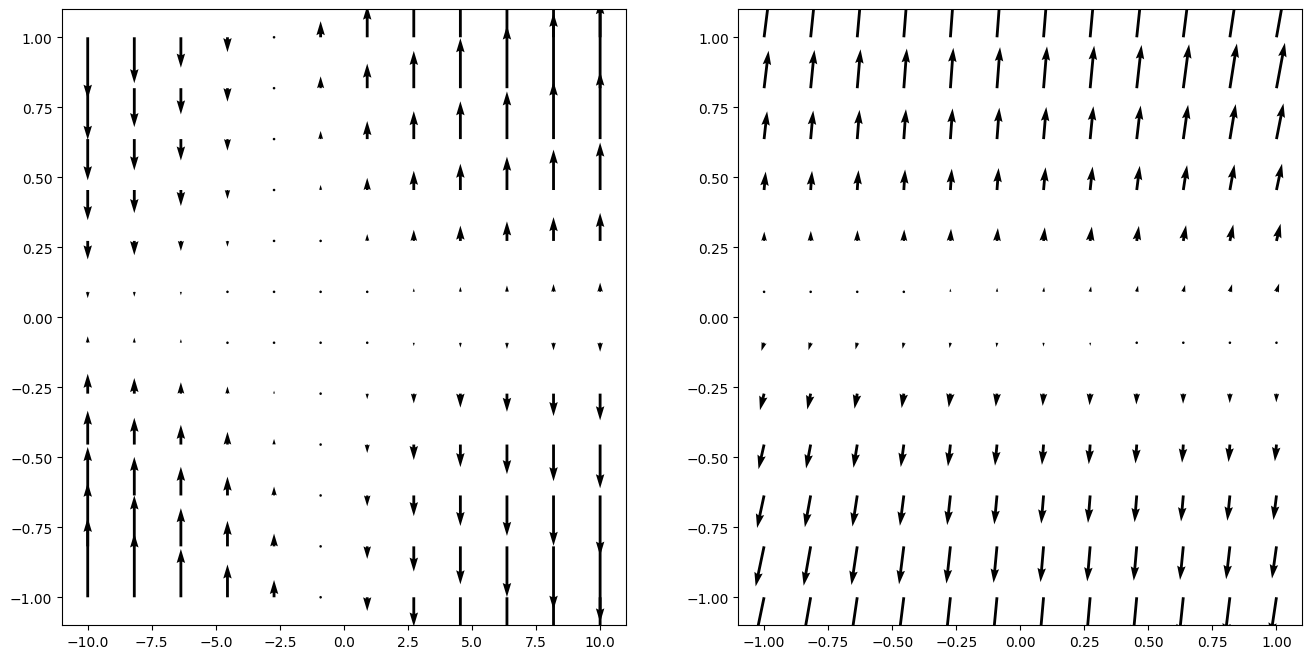

In [57]:
fig, (p1,p2) = plt.subplots(1,2,figsize=(16,8))

e_val = 10

p1.quiver(eG,yG,de(eG,yG),dy_func1(eG,yG))
p1.plot


p2.quiver(xP,yP,dx_og(e_val,xP,yP),dy_og(e_val,xP,yP))
# p2.plot(yv,h_func(e_val,yv))
plt.show()

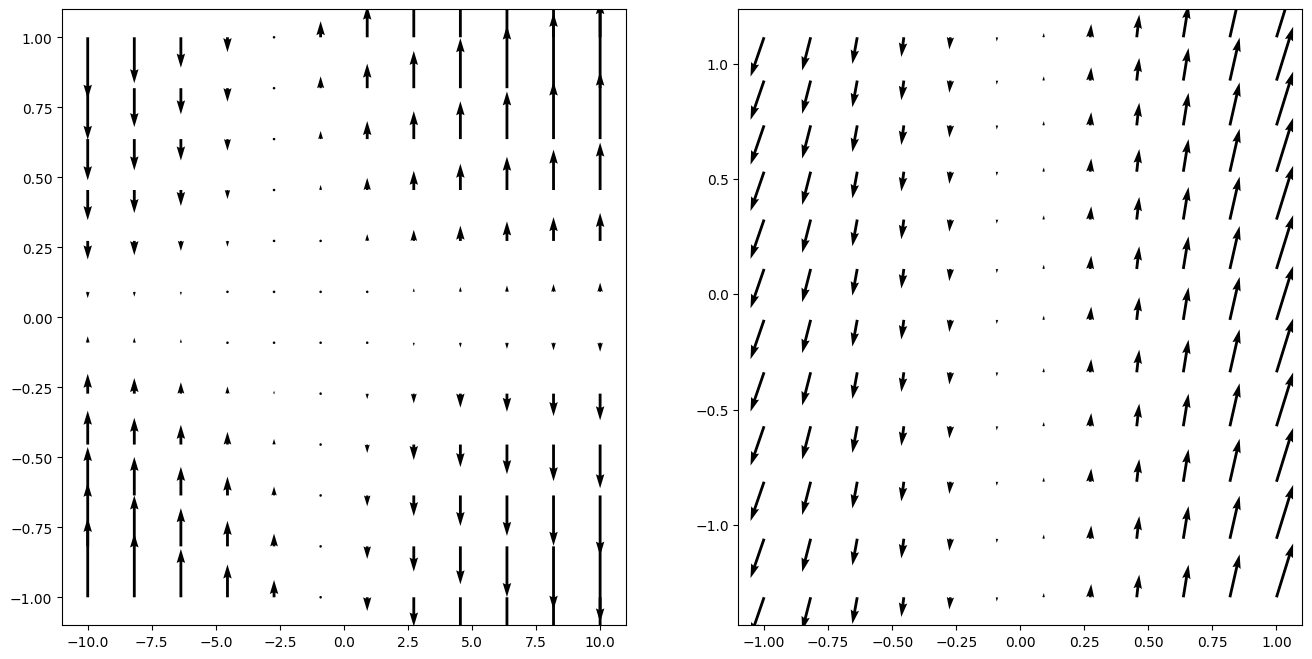

In [58]:
fig, (p1,p2) = plt.subplots(1,2,figsize=(16,8))

yv = np.linspace(-10,10,12)/10
e_val = 5
hv = h_func(e_val,yv)

ssGx, ssGy = np.meshgrid(yv,hv)

p1.quiver(eG,yG,de(eG,yG),dy_func1(eG,yG))

p2.quiver(ssGx,ssGy,dx_func(e_val,ssGx),dy_func1(e_val,ssGx))

plt.show()

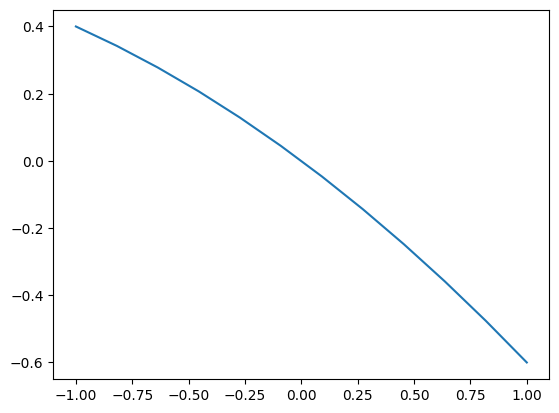

In [59]:
plt.plot(yv,h_func(0,yv))

# Problem 2

Compute the normal form for a map in the neighborhood of a fixed point having the linear part 

$$\begin{pmatrix}1&1\\0&1\end{pmatrix}$$

through second order terms. **Compare** your results to Ex 19.1.2, which has linear part.

$$\begin{pmatrix}0&1\\0&0\end{pmatrix}$$


---

$$L_J^k(h_k(y)) \equiv -(Dh_k(y)Jy-Jh_k(y))$$

In [60]:
x, y, J = smp.symbols('x y J')

h1 = smp.Matrix([[x**2],
                 [0]])
h2 = smp.Matrix([[x*y],
                 [0]])
h3 = smp.Matrix([[y**2],
                 [0]])
h4 = smp.Matrix([[0],
                 [x**2]])
h5 = smp.Matrix([[0],
                 [x*y]])
h6 = smp.Matrix([[0],
                 [y**2]])

H = [h1,h2,h3,h4,h5,h6]

J = smp.Matrix([[1,1],
                [0,1]])

v = smp.Matrix([[0],
                [y]])

In [61]:
h = H[0]
Dh = smp.Matrix([[smp.diff(h[0],x),smp.diff(h[0],y)],
                 [smp.diff(h[1],x),smp.diff(h[1],y)]])

L1 = J@h - Dh@J@v
# L1

In [62]:
h = H[1]
Dh = smp.Matrix([[smp.diff(h[0],x),smp.diff(h[0],y)],
                 [smp.diff(h[1],x),smp.diff(h[1],y)]])

L2 = J@h - Dh@J@v
# L2

In [63]:
h = H[2]
Dh = smp.Matrix([[smp.diff(h[0],x),smp.diff(h[0],y)],
                 [smp.diff(h[1],x),smp.diff(h[1],y)]])

L3 = J@h - Dh@J@v
# L3

In [64]:
h = H[3]
Dh = smp.Matrix([[smp.diff(h[0],x),smp.diff(h[0],y)],
                 [smp.diff(h[1],x),smp.diff(h[1],y)]])

L4 = J@h - Dh@J@v
# L4

In [65]:
h = H[4]
Dh = smp.Matrix([[smp.diff(h[0],x),smp.diff(h[0],y)],
                 [smp.diff(h[1],x),smp.diff(h[1],y)]])

L5 = J@h - Dh@J@v
# L5.expand()

In [66]:
h = H[5]
Dh = smp.Matrix([[smp.diff(h[0],x),smp.diff(h[0],y)],
                 [smp.diff(h[1],x),smp.diff(h[1],y)]])

L6 = J@h - Dh@J@v
# L6

In [67]:
L1

Matrix([
[x**2 - 2*x*y],
[           0]])

In [68]:
L2

Matrix([
[x*y - y*(x + y)],
[              0]])

In [69]:
L3

Matrix([
[-y**2],
[    0]])

In [70]:
L4

Matrix([
[        x**2],
[x**2 - 2*x*y]])

In [71]:
L5

Matrix([
[            x*y],
[x*y - y*(x + y)]])

In [72]:
L6

Matrix([
[ y**2],
[-y**2]])

In [73]:
G = smp.Matrix([[1,-2,0,0,0,0],
               [0,0,-1,0,0,0],
               [0,0,-1,0,0,0],
               [1,0,0,1,-2,0],
               [0,1,0,0,0,-1],
               [0,0,1,0,0,-1]]).T
G

Matrix([
[ 1,  0,  0,  1,  0,  0],
[-2,  0,  0,  0,  1,  0],
[ 0, -1, -1,  0,  0,  1],
[ 0,  0,  0,  1,  0,  0],
[ 0,  0,  0, -2,  0,  0],
[ 0,  0,  0,  0, -1, -1]])

In [74]:
smp.Matrix.left_eigenvects(G)[1]

(0, 2, [Matrix([[0, 0, 0, 2, 1, 0]])])

In [75]:
J@v

Matrix([
[y],
[y]])

$$\begin{align}\dot x =&\; y + 0 +\mathcal{O}(3)\\
\dot y =&\; y + a_1x^2 + a_2xy +\mathcal{O}(3) \end{align}$$ 

## EX 19.1.2

In [76]:
x, y, J = smp.symbols('x y J')

h1 = smp.Matrix([[x**2],
                 [0]])
h2 = smp.Matrix([[x*y],
                 [0]])
h3 = smp.Matrix([[y**2],
                 [0]])
h4 = smp.Matrix([[0],
                 [x**2]])
h5 = smp.Matrix([[0],
                 [x*y]])
h6 = smp.Matrix([[0],
                 [y**2]])

H = [h1,h2,h3,h4,h5,h6]

J = smp.Matrix([[0,1],
                [0,0]])

v = smp.Matrix([[0],
                [y]])

In [77]:
h = H[0]
Dh = smp.Matrix([[smp.diff(h[0],x),smp.diff(h[0],y)],
                 [smp.diff(h[1],x),smp.diff(h[1],y)]])

L1 = J@h - Dh@J@v

h = H[1]
Dh = smp.Matrix([[smp.diff(h[0],x),smp.diff(h[0],y)],
                 [smp.diff(h[1],x),smp.diff(h[1],y)]])

L2 = J@h - Dh@J@v

h = H[2]
Dh = smp.Matrix([[smp.diff(h[0],x),smp.diff(h[0],y)],
                 [smp.diff(h[1],x),smp.diff(h[1],y)]])

L3 = J@h - Dh@J@v

h = H[3]
Dh = smp.Matrix([[smp.diff(h[0],x),smp.diff(h[0],y)],
                 [smp.diff(h[1],x),smp.diff(h[1],y)]])

L4 = J@h - Dh@J@v

h = H[4]
Dh = smp.Matrix([[smp.diff(h[0],x),smp.diff(h[0],y)],
                 [smp.diff(h[1],x),smp.diff(h[1],y)]])

L5 = J@h - Dh@J@v

h = H[5]
Dh = smp.Matrix([[smp.diff(h[0],x),smp.diff(h[0],y)],
                 [smp.diff(h[1],x),smp.diff(h[1],y)]])

L6 = J@h - Dh@J@v

In [78]:
L1

Matrix([
[-2*x*y],
[     0]])

In [79]:
L2

Matrix([
[-y**2],
[    0]])

In [80]:
L3

Matrix([
[0],
[0]])

In [81]:
L4

Matrix([
[  x**2],
[-2*x*y]])

In [82]:
L5

Matrix([
[  x*y],
[-y**2]])

In [83]:
L6

Matrix([
[y**2],
[   0]])

In [84]:
G_ex = smp.Matrix([[0,-2,0,0,0,0],
               [0,0,-1,0,0,0],
               [0,0,0,0,0,0],
               [1,0,0,0,-2,0],
               [0,1,0,0,0,-1],
               [0,0,1,0,0,0]]).T
G_ex

Matrix([
[ 0,  0, 0,  1,  0, 0],
[-2,  0, 0,  0,  1, 0],
[ 0, -1, 0,  0,  0, 1],
[ 0,  0, 0,  0,  0, 0],
[ 0,  0, 0, -2,  0, 0],
[ 0,  0, 0,  0, -1, 0]])

In [85]:
smp.Matrix.left_eigenvects(G_ex)

[(0, 6, [Matrix([[0, 0, 0, 1, 0, 0]]), Matrix([[2, 0, 0, 0, 1, 0]])])]

In [86]:
smp.Matrix.left_eigenvects(G_ex)[0][2][1].T

Matrix([
[2],
[0],
[0],
[0],
[1],
[0]])

In [87]:
smp.Matrix.left_eigenvects(G_ex)[0][2][0].T

Matrix([
[0],
[0],
[0],
[1],
[0],
[0]])

$$\begin{align}\dot x =&\; y + a_1x^2 +\mathcal{O}(3)\\
\dot y =&\; 0 + a_2xy + a_3x^2 +\mathcal{O}(3) \end{align}$$ 